# Chapter 4 - Regression and Prediction

## Chapter summary
Regression predicts a numeric **response** (outcome) from one or more **predictors** (features). Historically used mostly for *explanation*; in data science mostly for *prediction*. Topics:

1. **Simple linear regression** - fitted line, residuals, least squares.
2. **Multiple linear regression** - several predictors; RMSE, RSE, $R^2$, t-statistics and p-values; model selection (AIC, stepwise).
3. **Prediction vs. explanation**, weighted regression.
4. **Factor (categorical) variables** - dummy variables, reference coding, many-level factors, ordered factors.
5. **Interpreting the regression equation** - correlated predictors, multicollinearity, confounding variables, interactions.
6. **Regression diagnostics** - outliers, influential values (Cook's distance, leverage), heteroskedasticity, partial residual plots.
7. **Polynomial and spline regression**, and **generalized additive models (GAMs)** for non-linear relationships.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"

def get_data(name):
    """Download a dataset of the book (once) into ./data and return its path."""
    path = Path("data") / name
    path.parent.mkdir(exist_ok=True)
    if not path.exists():
        urllib.request.urlretrieve(DATA_URL + name, path)
    return path

sns.set_style("whitegrid")

## 1. Simple Linear Regression

**Theory.** Models the relationship between a predictor $X$ and response $Y$ as a straight line:

$$ Y = b_0 + b_1 X + e $$

$b_0$ is the **intercept**, $b_1$ the **slope** (regression coefficient) - the change in $Y$ per unit change in $X$. The **fitted values** are $\hat{Y}_i=\hat b_0+\hat b_1X_i$ and the **residuals** $\hat e_i=Y_i-\hat Y_i$. The coefficients are estimated by **least squares**: minimise the **residual sum of squares** $RSS=\sum(Y_i-\hat Y_i)^2$. This has a closed-form solution but is sensitive to outliers.

Data: lung capacity (PEFR) of cotton workers vs. years of exposure.

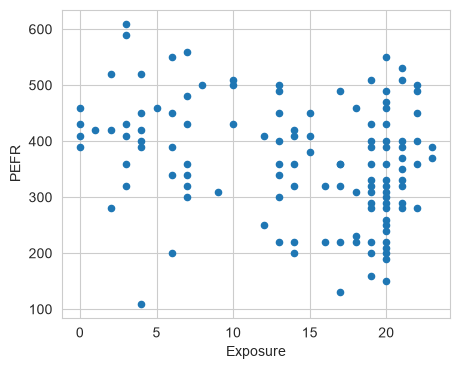

In [2]:
lung = pd.read_csv(get_data("LungDisease.csv"))
lung.plot.scatter(x="Exposure", y="PEFR", figsize=(5, 4))
plt.show()

Intercept: 424.583
Coefficient Exposure: -4.185


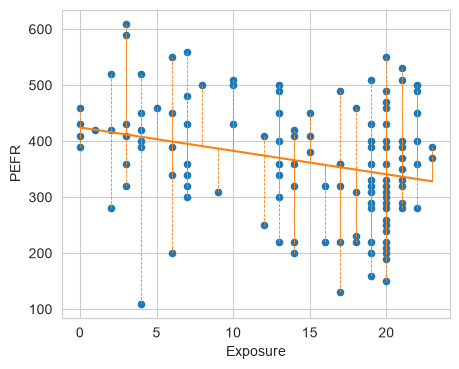

In [3]:
predictors = ["Exposure"]; outcome = "PEFR"
model = LinearRegression().fit(lung[predictors], lung[outcome])
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient Exposure: {model.coef_[0]:.3f}")

fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted

ax = lung.plot.scatter(x="Exposure", y="PEFR", figsize=(5, 4))
ax.plot(lung.Exposure, fitted, color="C1")
for x, yactual, yfitted in zip(lung.Exposure, lung.PEFR, fitted):
    ax.plot((x, x), (yactual, yfitted), "--", color="C1", lw=0.6)
plt.show()

## 2. Multiple Linear Regression

**Theory.** With $p$ predictors: $Y=b_0+b_1X_1+\dots+b_pX_p+e$. Key metrics:
* **RMSE** $=\sqrt{RSS/n}$ and **RSE** $=\sqrt{RSS/(n-p-1)}$ - typical size of the prediction error (RSE uses degrees of freedom).
* **$R^2$** - proportion of variance in $Y$ explained by the model (0-1). **Adjusted $R^2$** penalises extra predictors.
* **t-statistic** $=\hat b_j/SE(\hat b_j)$ and its p-value - test whether a coefficient differs from zero.
* **Cross-validation** estimates out-of-sample performance (holdout / k-fold).
* **Model selection**: *parsimony* (simplest adequate model); **AIC** $=2P+n\log(RSS/n)$ penalises complexity; **stepwise / forward / backward selection** and **penalised regression** (ridge, lasso) search for good subsets.

Data: house sales in King County (Seattle).

In [4]:
house = pd.read_csv(get_data("house_sales.csv"), sep="\t")
subset = ["AdjSalePrice", "SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]
print(house[subset].head())

   AdjSalePrice  SqFtTotLiving  SqFtLot  Bathrooms  Bedrooms  BldgGrade
1      300805.0           2400     9373       3.00         6          7
2     1076162.0           3764    20156       3.75         4         10
3      761805.0           2060    26036       1.75         4          8
4      442065.0           3200     8618       3.75         5          7
5      297065.0           1720     8620       1.75         4          7


In [5]:
predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]
outcome = "AdjSalePrice"
house_lm = LinearRegression().fit(house[predictors], house[outcome])
print(f"Intercept: {house_lm.intercept_:.3f}")
print("Coefficients:")
for name, coef in zip(predictors, house_lm.coef_):
    print(f" {name}: {coef:.3f}")

Intercept: -521871.368
Coefficients:
 SqFtTotLiving: 228.831
 SqFtLot: -0.060
 Bathrooms: -19442.840
 Bedrooms: -47769.955
 BldgGrade: 106106.963


In [6]:
fitted = house_lm.predict(house[predictors])
RMSE = np.sqrt(mean_squared_error(house[outcome], fitted))
r2 = r2_score(house[outcome], fitted)
print(f"RMSE: {RMSE:.0f}, r2: {r2:.4f}")

RMSE: 261220, r2: 0.5406


`statsmodels` gives the full table with standard errors, t-statistics and p-values:

In [7]:
model = sm.OLS(house[outcome], house[predictors].assign(const=1))
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:27:51   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   228.8306      3.899     58.694

**Model selection with stepwise regression** (here: a forward search on AIC, implemented manually).

In [8]:
y = house[outcome]
house_full = sm.add_constant(house[["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade",
                                    "PropertyType", "NbrLivingUnits", "SqFtFinBasement", "YrBuilt", "YrRenovated"]]
                              .pipe(pd.get_dummies, columns=["PropertyType"], drop_first=True).astype(float))

def stepwise_aic(y, X, start_cols=("const",)):
    selected = list(start_cols)
    best_aic = sm.OLS(y, X[selected]).fit().aic
    while True:
        # forward step: add the variable that lowers AIC the most
        trials = {c: sm.OLS(y, X[selected + [c]]).fit().aic for c in X.columns if c not in selected}
        if not trials:
            break
        best_c = min(trials, key=trials.get)
        if trials[best_c] >= best_aic - 1e-6:
            break
        selected.append(best_c)
        best_aic = trials[best_c]
    return selected, best_aic

selected, aic = stepwise_aic(y, house_full)
print("Selected predictors:", selected)
print("AIC:", round(aic, 1))

Selected predictors: ['const', 'SqFtTotLiving', 'BldgGrade', 'YrBuilt', 'Bedrooms', 'Bathrooms', 'PropertyType_Townhouse', 'SqFtFinBasement', 'PropertyType_Single Family']
AIC: 627523.0


**Weighted regression.** Observations can be given different weights (e.g. more recent sales are more reliable). Using the year of sale as the weight:

In [9]:
house["Year"] = pd.to_datetime(house["DocumentDate"]).dt.year
house["Weight"] = house.Year - 2005
house_wt = sm.WLS(house[outcome], house[predictors].assign(const=1), weights=house["Weight"]).fit()
print(pd.DataFrame({"unweighted": results.params, "weighted": house_wt.params}).round(1))

               unweighted  weighted
SqFtTotLiving       228.8     245.0
SqFtLot              -0.1      -0.3
Bathrooms        -19442.8  -26086.0
Bedrooms         -47770.0  -53608.9
BldgGrade        106107.0  115242.4
const           -521871.4 -584189.3


### Cross-validation and regularisation

A model always fits the data it was trained on better than new data - the extra predictors you add will lower the training error even if they are noise (**overfitting**). The honest question is how well the model predicts *unseen* records. **Holdout validation** trains on one part of the data and tests on the rest; **k-fold cross-validation** repeats this $k$ times, each time holding out a different fold, and averages the error - a more stable estimate that uses all the data.

**Regularisation** attacks overfitting by penalising large coefficients: **ridge** adds $\lambda\sum b_j^2$ (shrinks all coefficients towards zero), **lasso** adds $\lambda\sum |b_j|$ (can shrink some coefficients *exactly* to zero, so it also selects variables). The penalty strength $\lambda$ is itself chosen by cross-validation. Predictors must be standardised first, otherwise the penalty depends on the units.

In [10]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_cv, y_cv = house[predictors], house[outcome]
folds = KFold(n_splits=5, shuffle=True, random_state=1)
rmse_cv = -cross_val_score(LinearRegression(), X_cv, y_cv, cv=folds, scoring="neg_root_mean_squared_error")
print("5-fold CV RMSE per fold:", rmse_cv.round(0), "| mean:", round(rmse_cv.mean()))

lasso = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=1)).fit(X_cv, y_cv)
print("Lasso coefficients (standardised predictors):")
print(pd.Series(lasso[-1].coef_, index=predictors).round(0))

5-fold CV RMSE per fold: [246892. 288347. 256308. 270674. 242404.] | mean: 260925
Lasso coefficients (standardised predictors):
SqFtTotLiving    207725.0
SqFtLot           -1347.0
Bathrooms        -13829.0
Bedrooms         -42666.0
BldgGrade        125051.0
dtype: float64


## 3. Prediction using regression

**Theory.** A prediction has two kinds of uncertainty: a **confidence interval** for the *mean* response at given X (uncertainty in coefficients), and the wider **prediction interval** for an *individual* new value (adds the residual noise). Beware of **extrapolation** beyond the range of the training data.

In [11]:
new_house = pd.DataFrame({"SqFtTotLiving": [2000], "SqFtLot": [8000], "Bathrooms": [2.5], "Bedrooms": [3], "BldgGrade": [8], "const": [1]})
pred = results.get_prediction(new_house[results.params.index]).summary_frame(alpha=0.05)
print(pred)

            mean      mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  592244.842532  2449.116019  587444.407167  597045.277896  80145.121459   

   obs_ci_upper  
0  1.104345e+06  


**Prediction versus explanation.** Regression has two historic purposes. In *explanation* (the traditional statistics view) we care about the **coefficients**: how much does price change per extra square foot, is the effect statistically significant, and what does it mean? Here interpretability, p-values and causal reasoning (confounders!) matter most. In *prediction* (the data-science view) we care about **accuracy on new records**: a model with unstable or uninterpretable coefficients is fine as long as its out-of-sample error is low. This is why data scientists lean on cross-validation, regularisation and even non-linear models (Chapter 6), while the t-statistics and p-values are used mostly to decide which predictors to keep. Also remember **extrapolation** is dangerous: a regression says nothing about regions of predictor space where no data were observed, and prediction intervals understate the real uncertainty there.

**Adjusted $R^2$** corrects $R^2$ for the number of predictors: $R^2_{adj}=1-(1-R^2)\frac{n-1}{n-p-1}$, so adding a useless predictor can lower it.

## 4. Factor variables in regression

**Theory.** Categorical predictors are converted to **dummy (indicator) variables** (one-hot encoding). With $P$ levels, $P-1$ dummies are used - the omitted level is the **reference level** and each coefficient is the difference vs. that reference. (Using all $P$ levels causes perfect multicollinearity.)
* **Many-level factors** (e.g. zip code with 80+ values) can be consolidated into fewer groups, e.g. by the median residual of an initial model (as below).
* **Ordered factors** (e.g. building grade) can be converted to a numeric score.

In [12]:
print(house.PropertyType.value_counts())
print(pd.get_dummies(house["PropertyType"]).head(3))

X = pd.get_dummies(house[["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade", "PropertyType"]],
                   drop_first=True).astype(float)
house_lm_factor = LinearRegression().fit(X, house[outcome])
print("Intercept:", round(house_lm_factor.intercept_, 1))
for n_, c_ in zip(X.columns, house_lm_factor.coef_):
    print(f"  {n_}: {c_:.2f}")

PropertyType
Single Family    20720
Townhouse         1710
Multiplex          257
Name: count, dtype: int64
   Multiplex  Single Family  Townhouse
1       True          False      False
2      False           True      False
3      False           True      False
Intercept: -446841.4
  SqFtTotLiving: 223.37
  SqFtLot: -0.07
  Bathrooms: -15979.01
  Bedrooms: -50889.73
  BldgGrade: 109416.31
  PropertyType_Single Family: -84678.22
  PropertyType_Townhouse: -115121.98


**Handling zip codes (many levels).** Fit a model without zip, compute median residual per zip, cluster zips into 5 groups by that median, and use `ZipGroup` as a factor.

In [13]:
resid_df = pd.DataFrame({"ZipCode": house["ZipCode"],
                         "residual": house[outcome] - house_lm.predict(house[predictors])})
zip_groups = (resid_df.groupby("ZipCode")["residual"].agg(["median", "count"])
              .reset_index().sort_values("median"))
zip_groups["cum_count"] = np.cumsum(zip_groups["count"])
zip_groups["ZipGroup"] = pd.qcut(zip_groups["cum_count"], 5, labels=False)
to_join = zip_groups[["ZipCode", "ZipGroup"]].set_index("ZipCode")
house = house.join(to_join, on="ZipCode")
house["ZipGroup"] = house["ZipGroup"].astype(int)
print(house.groupby("ZipGroup")[outcome].median())

ZipGroup
0    368592.0
1    483965.5
2    450621.0
3    442540.0
4    624781.0
Name: AdjSalePrice, dtype: float64


## 5. Interpreting the regression equation

**Theory.**
* **Correlated predictors**: coefficients can change sign or magnitude once other variables are added (e.g. *Bedrooms* negative after controlling for total living area) - the coefficient is the effect *holding other predictors fixed*.
* **Multicollinearity**: highly correlated predictors make coefficients unstable. Detect it with the **variance inflation factor (VIF)**; VIF > 5 is a warning sign. Remedy: drop or combine variables.
* **Confounding variable**: an omitted variable correlated with both predictor and response, biasing the estimates (e.g. omitting location).
* **Interactions**: the effect of one predictor depends on another's value (e.g. value of extra living space depends on location). Include with $X_1 \times X_2$ (`*` in a formula).

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
Xv = house[predictors].assign(const=1)
vif = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1] - 1)], index=predictors)
print("VIF:\n", vif.round(2))

VIF:
 SqFtTotLiving    4.22
SqFtLot          1.05
Bathrooms        2.58
Bedrooms         1.69
BldgGrade        2.66
dtype: float64


**Demonstration 1 - correlated predictors change coefficients.** On its own, more bedrooms means a more expensive house (positive coefficient). But bedrooms are strongly related to total living area. Once living area is in the model, the coefficient of *Bedrooms* measures the effect of an extra bedroom **holding total size fixed** - i.e. the same space cut into smaller rooms - and it can turn negative. A coefficient is therefore never "the effect of that variable" in isolation; it is conditional on every other predictor in the model.

In [15]:
simple = smf.ols("AdjSalePrice ~ Bedrooms", data=house).fit()
multi = smf.ols("AdjSalePrice ~ SqFtTotLiving + Bedrooms", data=house).fit()
print(f"Bedrooms coefficient alone                : {simple.params['Bedrooms']:>10,.0f}")
print(f"Bedrooms coefficient, controlling for size: {multi.params['Bedrooms']:>10,.0f}")

Bedrooms coefficient alone                :    132,991
Bedrooms coefficient, controlling for size:    -70,113


**Demonstration 2 - multicollinearity inflates standard errors.** We add a near-duplicate of living area (the same number plus a little noise). Predictions barely change, but the model can no longer tell the two copies apart, so the standard errors (uncertainty) of their coefficients blow up and the coefficients become unstable. This is exactly what a high VIF warns about.

In [16]:
rng = np.random.default_rng(1)
h = house.assign(SqFtCopy=house["SqFtTotLiving"] + rng.normal(0, 30, len(house)))
m0 = smf.ols("AdjSalePrice ~ SqFtTotLiving + Bathrooms + Bedrooms + BldgGrade", data=h).fit()
m1 = smf.ols("AdjSalePrice ~ SqFtTotLiving + SqFtCopy + Bathrooms + Bedrooms + BldgGrade", data=h).fit()
print(f"SqFtTotLiving: coef={m0.params['SqFtTotLiving']:>8,.0f}  std.err={m0.bse['SqFtTotLiving']:>6,.1f}   (without the duplicate)")
print(f"SqFtTotLiving: coef={m1.params['SqFtTotLiving']:>8,.0f}  std.err={m1.bse['SqFtTotLiving']:>6,.1f}   (with the duplicate)")
print(f"R2 without: {m0.rsquared:.4f}   R2 with: {m1.rsquared:.4f}   <- fit is the same, inference is not")

SqFtTotLiving: coef=     228  std.err=   3.9   (without the duplicate)
SqFtTotLiving: coef=     302  std.err=  58.3   (with the duplicate)
R2 without: 0.5406   R2 with: 0.5406   <- fit is the same, inference is not


In [17]:
model = smf.ols(formula="AdjSalePrice ~ SqFtTotLiving*C(ZipGroup) + SqFtLot + Bathrooms + Bedrooms + BldgGrade + PropertyType",
                data=house)
results_inter = model.fit()
print(results_inter.summary().tables[1])
print("R2 with interaction:", round(results_inter.rsquared, 4))

                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                      -4.853e+05   2.05e+04    -23.701      0.000   -5.25e+05   -4.45e+05
C(ZipGroup)[T.1]               -1.113e+04   1.34e+04     -0.830      0.407   -3.74e+04    1.52e+04
C(ZipGroup)[T.2]                2.032e+04   1.18e+04      1.717      0.086   -2877.441    4.35e+04
C(ZipGroup)[T.3]                 2.05e+04   1.21e+04      1.697      0.090   -3180.870    4.42e+04
C(ZipGroup)[T.4]               -1.499e+05   1.13e+04    -13.285      0.000   -1.72e+05   -1.28e+05
PropertyType[T.Single Family]   1.357e+04   1.39e+04      0.975      0.330   -1.37e+04    4.09e+04
PropertyType[T.Townhouse]      -5.884e+04   1.51e+04     -3.888      0.000   -8.85e+04   -2.92e+04
SqFtTotLiving                    114.7650      4.863     23.600      0.000     105.233     124.297
SqFtTotLiv

## 6. Regression diagnostics

**Theory.**
* **Outliers**: cases with large **standardized residuals** (residual divided by RSE; > 2-3 is suspicious).
* **Influential values**: cases whose removal changes the regression noticeably. **Leverage** (hat value) measures how unusual a case's predictor values are; **Cook's distance** combines leverage and residual size.
* **Heteroskedasticity**: non-constant residual variance - seen as a funnel in plots of |residual| vs. fitted. It does not bias coefficients but invalidates standard errors and may mean a missing predictor.
* **Non-normal residuals** matter little for large samples; check with a QQ-plot.
* **Partial residual plots** show the relationship between response and one predictor after accounting for the others, revealing non-linearity.

We use houses in zip code 98105.

In [18]:
house_98105 = house.loc[house["ZipCode"] == 98105, :]
predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]
outcome = "AdjSalePrice"
house_outlier = sm.OLS(house_98105[outcome], house_98105[predictors].assign(const=1))
result_98105 = house_outlier.fit()

influence = result_98105.get_influence()
sresiduals = influence.resid_studentized_internal
idx = sresiduals.argmin()
print("Most extreme standardized residual:", round(sresiduals[idx], 2))
print(house_98105.loc[house_98105.index[idx], [outcome] + predictors])

Most extreme standardized residual: -4.33
AdjSalePrice     119748.0
SqFtTotLiving      2900.0
SqFtLot            7276.0
Bathrooms             3.0
Bedrooms              6.0
BldgGrade             7.0
Name: 24333, dtype: float64


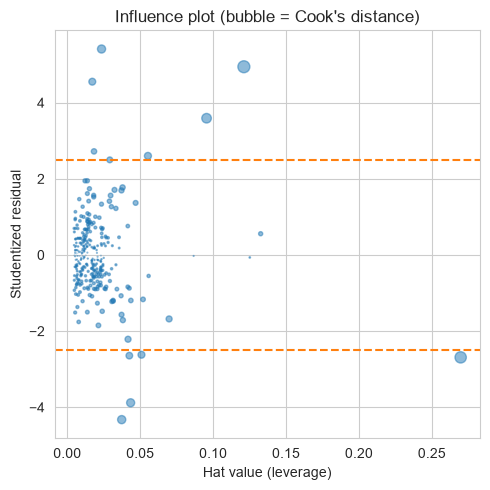

In [19]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(influence.hat_matrix_diag, influence.resid_studentized_internal, s=100 * np.sqrt(influence.cooks_distance[0]),
           alpha=0.5)
ax.axhline(-2.5, ls="--", color="C1"); ax.axhline(2.5, ls="--", color="C1")
ax.set_xlabel("Hat value (leverage)"); ax.set_ylabel("Studentized residual")
ax.set_title("Influence plot (bubble = Cook's distance)")
plt.tight_layout(); plt.show()

In [20]:
# refit without the influential points
mask = [dist < 0.08 for dist in influence.cooks_distance[0]]
house_infl = house_98105.loc[mask]
result_infl = sm.OLS(house_infl[outcome], house_infl[predictors].assign(const=1)).fit()
print(pd.DataFrame({"original": result_98105.params, "influential removed": result_infl.params}).round(1))

               original  influential removed
SqFtTotLiving     209.6                230.1
SqFtLot            38.9                 33.1
Bathrooms        2282.3             -16131.9
Bedrooms       -26320.3             -22887.9
BldgGrade      130000.1             114870.6
const         -772549.9            -647137.1


**Heteroskedasticity** and residual distribution:

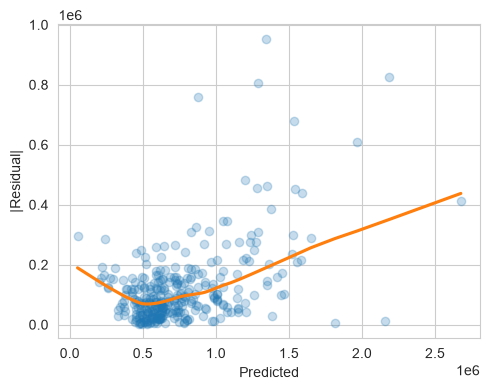

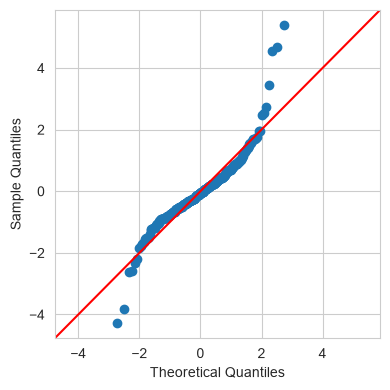

In [21]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.regplot(x=result_98105.fittedvalues, y=np.abs(result_98105.resid),
            scatter_kws={"alpha": 0.25}, line_kws={"color": "C1"}, lowess=True, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("|Residual|")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(4, 4))
sm.qqplot(result_98105.resid, fit=True, line="45", ax=ax)
plt.tight_layout(); plt.show()

**Partial residual plot** for living area. The partial residual for predictor $X_i$ is $\text{residual}+\hat b_i X_i$: the part of the response left over after removing the effect of all *other* predictors. Plotted against $X_i$, it shows the relationship the model is trying to capture. The straight line is the model's assumption ($\hat b_i X_i$); the LOWESS smooth is what the data actually say. If the smooth bends away from the line, the relationship is **non-linear** and the predictor needs a polynomial or spline (next section).

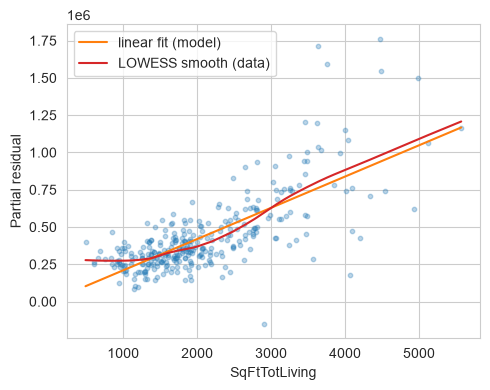

In [22]:
from statsmodels.nonparametric.smoothers_lowess import lowess

b = result_98105.params["SqFtTotLiving"]
x_ = house_98105["SqFtTotLiving"]
partial_resid = result_98105.resid + b * x_
smooth = lowess(partial_resid, x_, frac=0.5)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x_, partial_resid, alpha=0.3, s=10)
xs = np.sort(x_.values)
ax.plot(xs, b * xs, color="C1", label="linear fit (model)")
ax.plot(smooth[:, 0], smooth[:, 1], color="C3", label="LOWESS smooth (data)")
ax.set_xlabel("SqFtTotLiving"); ax.set_ylabel("Partial residual"); ax.legend()
plt.tight_layout(); plt.show()

## 7. Polynomial and spline regression

**Theory.** Add polynomial terms ($X$, $X^2$, ...) to fit curves while staying linear in the *coefficients*. **Splines** fit separate low-degree polynomials in intervals between **knots**, joined smoothly - more flexible and stable than high-degree polynomials. **Generalized additive models (GAMs)** automate spline fitting: $Y=b_0+f_1(X_1)+f_2(X_2)+\dots$ with each $f_j$ a smooth spline.

In [23]:
model_poly = smf.ols(
    formula="AdjSalePrice ~ SqFtTotLiving + np.power(SqFtTotLiving, 2) + SqFtLot + Bathrooms + Bedrooms + BldgGrade",
    data=house_98105)
result_poly = model_poly.fit()
print(result_poly.summary().tables[1])

                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                  -6.159e+05   1.03e+05     -5.953      0.000   -8.19e+05   -4.12e+05
SqFtTotLiving                  7.4521     55.418      0.134      0.893    -101.597     116.501
np.power(SqFtTotLiving, 2)     0.0388      0.010      4.040      0.000       0.020       0.058
SqFtLot                       32.5594      5.436      5.990      0.000      21.863      43.256
Bathrooms                  -1435.1231   1.95e+04     -0.074      0.941   -3.99e+04     3.7e+04
Bedrooms                   -9191.9441   1.33e+04     -0.693      0.489   -3.53e+04    1.69e+04
BldgGrade                   1.357e+05   1.49e+04      9.087      0.000    1.06e+05    1.65e+05


In [24]:
knots = [1000, 1700, 2350]
model_spline = smf.ols(
    formula="AdjSalePrice ~ bs(SqFtTotLiving, knots=knots, degree=3) + SqFtLot + Bathrooms + Bedrooms + BldgGrade",
    data=house_98105)
result_spline = model_spline.fit()
print("R2 linear:", round(result_98105.rsquared, 4), " poly:", round(result_poly.rsquared, 4),
      " spline:", round(result_spline.rsquared, 4))

R2 linear: 0.7954  poly: 0.8058  spline: 0.8137


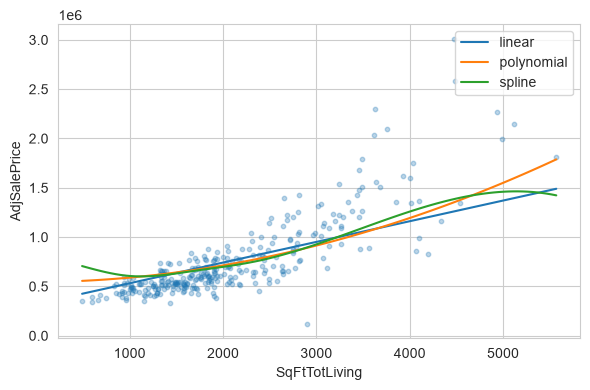

In [25]:
# Compare the fitted curves for SqFtTotLiving (other predictors held at their means)
sq = np.linspace(house_98105.SqFtTotLiving.min(), house_98105.SqFtTotLiving.max(), 100)
grid = pd.DataFrame({"SqFtTotLiving": sq,
                     "SqFtLot": house_98105.SqFtLot.mean(), "Bathrooms": house_98105.Bathrooms.mean(),
                     "Bedrooms": house_98105.Bedrooms.mean(), "BldgGrade": house_98105.BldgGrade.mean()})
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(house_98105.SqFtTotLiving, house_98105.AdjSalePrice, alpha=0.3, s=10)
ax.plot(sq, result_98105.predict(grid.assign(const=1)[result_98105.params.index]), label="linear")
ax.plot(sq, result_poly.predict(grid), label="polynomial")
ax.plot(sq, result_spline.predict(grid), label="spline")
ax.set_xlabel("SqFtTotLiving"); ax.set_ylabel("AdjSalePrice"); ax.legend()
plt.tight_layout(); plt.show()

**Generalized additive model** with `pygam` (spline on living area, linear on the rest):

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     11.3413
Link Function:                     IdentityLink Log Likelihood:                                 -4206.1343
Number of Samples:                          313 AIC:                                             8436.9512
                                                AICc:                                            8438.0501
                                                GCV:                                      30525464859.9718
                                                Scale:                                          168941.408
                                                Pseudo R-Squared:                                   0.8199
Feature Function                  Lam

C:\Users\tatak\AppData\Local\Temp\ipykernel_14780\2529896307.py:7: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


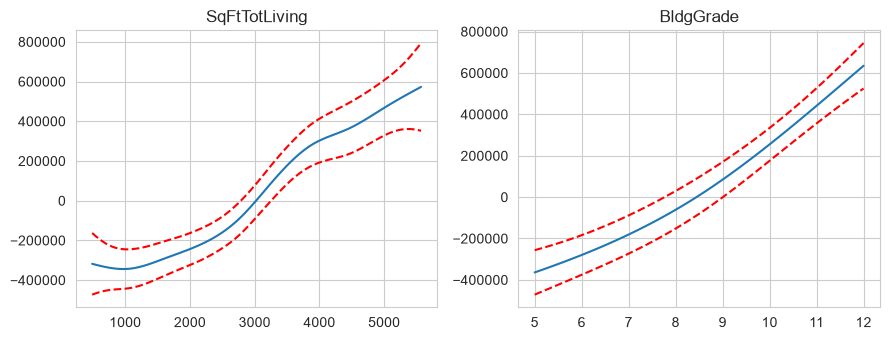

In [26]:
try:
    from pygam import LinearGAM, s, l

    X_gam = house_98105[predictors].values
    y_gam = house_98105[outcome].values
    gam = LinearGAM(s(0, n_splines=12) + l(1) + l(2) + l(3) + s(4, n_splines=5)).fit(X_gam, y_gam)
    gam.summary()

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    for i, ax in zip((0, 4), axes):
        XX = gam.generate_X_grid(term=i)
        pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
        ax.plot(XX[:, i], pdep)
        ax.plot(XX[:, i], confi, c="r", ls="--")
        ax.set_title(predictors[i])
    plt.tight_layout(); plt.show()
except Exception as err:      # pygam is old and occasionally breaks with new SciPy/NumPy versions
    print("pygam could not run here:", repr(err))
    print("Fix: pip install -U pygam   (or skip this cell - the spline model above already shows the idea).")

## Key takeaways
* Least-squares regression is the workhorse for numeric prediction; judge it with RMSE / RSE / $R^2$ and test coefficients with t-statistics.
* Use dummy variables for factors; watch for multicollinearity (VIF), confounders, and interactions.
* Diagnose with standardized residuals, leverage / Cook's distance, heteroskedasticity checks and partial residual plots.
* Polynomials, splines and GAMs capture non-linear relationships; use cross-validation to avoid overfitting.